In [1]:
import numpy as np
from pygmid import Lookup as lk
import matplotlib.pyplot as plt

# Load technology data
NCH = lk('ihp-sg13g2_lookup/simulation/sg13_lv_nmos.mat')
PCH = lk('ihp-sg13g2_lookup/simulation/sg13_lv_pmos.mat')

VDD = 1.2  # Supply voltage in volts

In [2]:
# ===================================
# User Specifications & Inductor Data
# ===================================
f_min = 2.40e9       # Minimum frequency (Hz)
f_max = 2.48e9       # Maximum frequency (Hz)
f_c = (f_min + f_max) / 2.0  # Center frequency (Hz)

L_diff = 4.0e-9      # Total Differential Inductance (H)
Q_L = 16.8           # Inductor Quality Factor
f_SR = 9.5e9         # Inductor Self-Resonance Frequency (Hz)

alpha = 2.0          # Startup safety margin

In [3]:
# ======================================
# Tank & Inductor Parasitic Calculations
# ======================================
w_c = 2 * np.pi * f_c
    
# Total differential capacitance needed across the tank to hit f_c
C_tot_diff = 1.0 / ((w_c**2) * L_diff)

# Inductor parallel resistance at resonance
R_p = Q_L * w_c * L_diff

# Calculate Inductor parasitic capacitance from SRF (Differential)
w_SR = 2 * np.pi * f_SR
C_ind_par_diff = 1.0 / ((w_SR**2) * L_diff)

print(f"Total Differential Tank Capacitance: {C_tot_diff*1e12:.4f} pF")
print(f"Inductor Parallel Resistance at Resonance: {R_p*1e-3:.4f} kOhms")
print(f"Inductor Parasitic Capacitance: {C_ind_par_diff*1e12:.4f} pF")

Total Differential Tank Capacitance: 1.0637 pF
Inductor Parallel Resistance at Resonance: 1.0302 kOhms
Inductor Parasitic Capacitance: 0.0702 pF


In [4]:
# ==================================
# Transconductance (gm) Requirements
# ==================================
# gm_req is the total transconductance needed to overcome tank losses
gm_req_total = (2 * alpha) / R_p

# For a symmetric output, split equally between NMOS and PMOS pairs
gm_min = gm_req_total / 2.0

print(f"Minimum Transconductance per Device (NMOS/PMOS): {gm_min*1e3:.4f} mS")

Minimum Transconductance per Device (NMOS/PMOS): 1.9413 mS


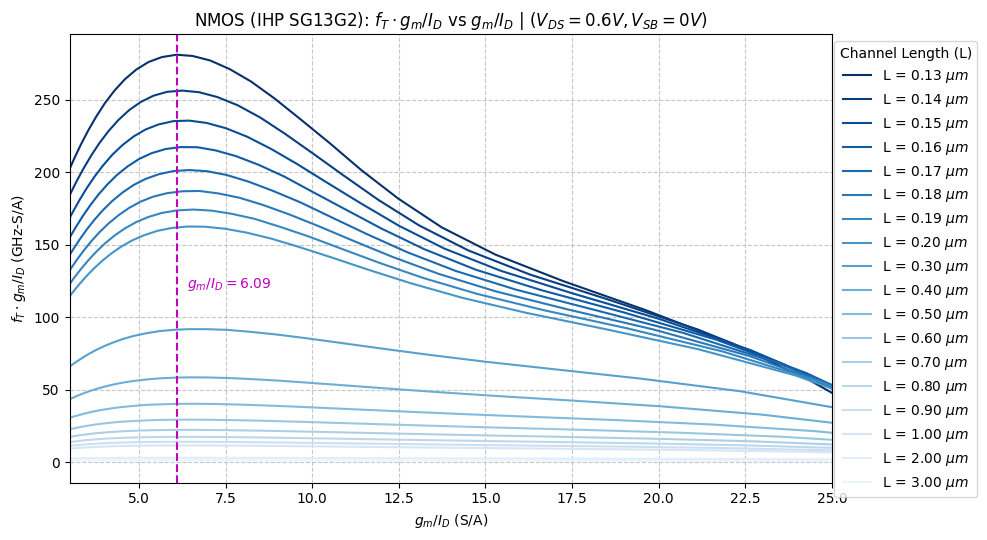

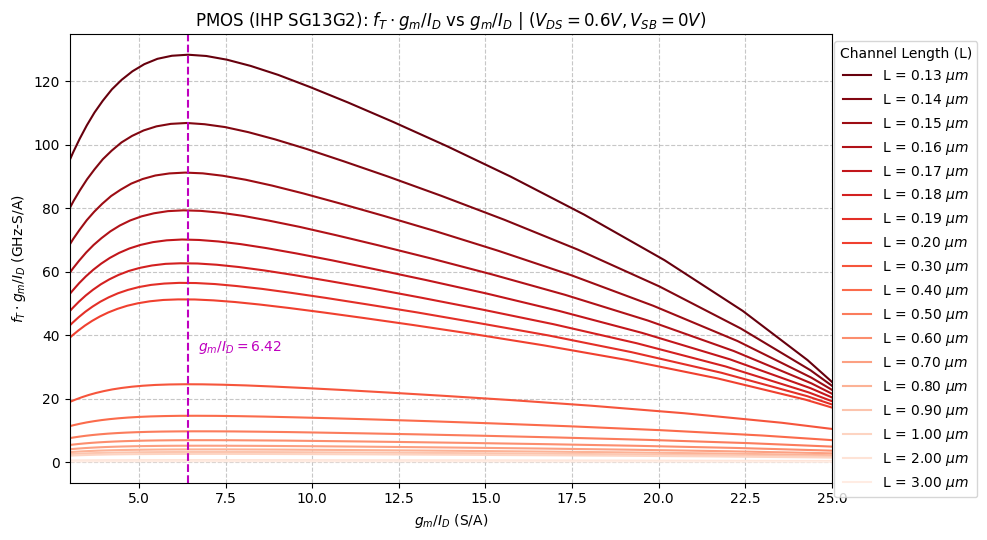

In [5]:
# =====================================
# NMOS & PMOS fT.(gm/ID) VS gm/ID PLOTS
# =====================================
# Plotting Function
def plot_ftgmid_vs_gmid(device_data, device_name, color_map):
    plt.figure(figsize=(10, 5.5))
    
    # Extract all available Lengths from the LUT
    L_values = np.unique(device_data['L'])

    # Loop through each 'L' and plot
    for i, L_val in enumerate(L_values):
        # Look up 'GM_ID' while sweeping VGS, holding L, VDS, and VSB constant
        gm_ID = device_data.lookup('GM_ID', VDS=VDD/2, VSB=0, L=L_val)
        fT = device_data.lookup('GM_CGG', VDS=VDD/2, VSB=0, L=L_val)/2/np.pi

        if i == 0:
            # Find gm/ID corresponding to maximum ft*gm/ID for annotation at L = 0.13μm
            max_index = np.argmax(gm_ID*fT*1e-9)
            gm_ID_max = gm_ID[max_index]
        
        # Plotting
        plt.plot(gm_ID, gm_ID*fT*1e-9, label=rf'L = {L_val:.2f} $\mu m$', color=color_map(i / len(L_values)))

    # Formatting the Plot
    plt.title(fr'{device_name}: $f_T\cdot g_m/I_D$ vs $g_m/I_D$ | ($V_{{DS}}={VDD/2}V, V_{{SB}}={0}V$)')
    plt.xlabel(r'$g_m/I_D$ (S/A)')
    plt.ylabel(r'$f_T\cdot g_m/I_D$ (GHz-S/A)')
    plt.xlim(3, 25)

    # Vertical gm/ID requirement line
    plt.axvline(x=gm_ID_max, color='m', linestyle='--')
    if device_name.startswith("NMOS"):
        plt.text(gm_ID_max+0.3, 120, f'$g_m/I_D = {gm_ID_max:.2f}$', color='m')
    else:
        plt.text(gm_ID_max+0.3, 35, f'$g_m/I_D = {gm_ID_max:.2f}$', color='m')

    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.2, 1), loc='upper right', title="Channel Length (L)")
    plt.tight_layout()
    plt.show()

# Generate Plots
plot_ftgmid_vs_gmid(NCH, "NMOS (IHP SG13G2)", plt.cm.Blues_r)
plot_ftgmid_vs_gmid(PCH, "PMOS (IHP SG13G2)", plt.cm.Reds_r)

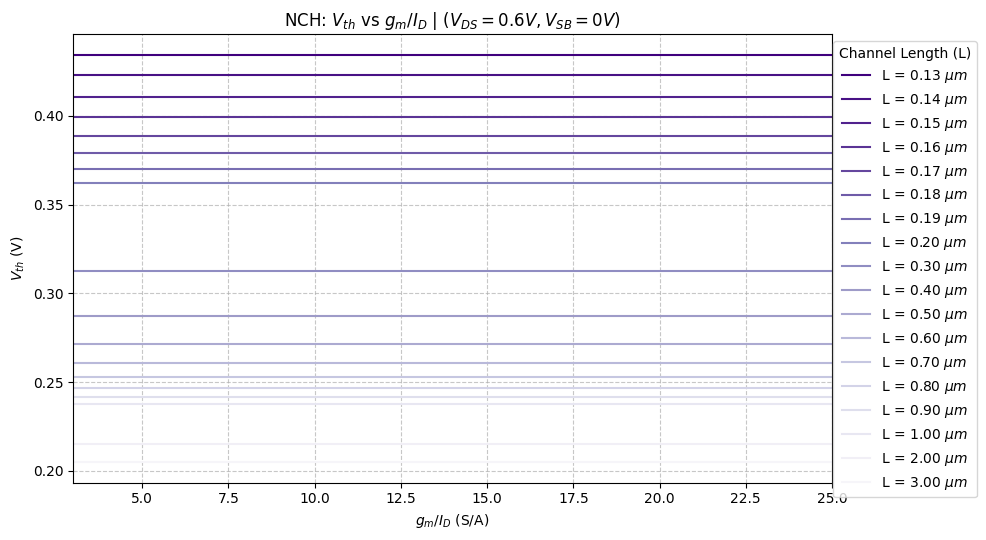

In [6]:
# ==============================
# NMOS & PMOS Vth VS gm/ID PLOTS
# ==============================
fig = plt.figure(figsize=(10, 5.5))

L_values = np.unique(NCH['L'])
color_map = plt.cm.Purples_r

# Loop through each 'L' and plot
for i, L_val in enumerate(L_values):
    # Look up 'GM_ID' while sweeping VGS, holding L, VDS, and VSB constant
    gm_ID = NCH.lookup('GM_ID', VDS=VDD/2, VSB=0, L=L_val)
    vth = NCH.lookup('VT', VDS=VDD/2, VSB=0, L=L_val)
    
    # Plotting
    plt.plot(gm_ID, vth, label=rf'L = {L_val:.2f} $\mu m$', color=color_map(i / len(L_values)))

# Formatting the Plot
plt.title(fr'NCH: $V_{{th}}$ vs $g_m/I_D$ | ($V_{{DS}}={VDD/2}V, V_{{SB}}={0}V$)')
plt.xlabel(r'$g_m/I_D$ (S/A)')
plt.ylabel(r'$V_{{th}}$ (V)')
plt.xlim(3, 25)

plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.2, 1), loc='upper right', title="Channel Length (L)")
plt.tight_layout()
plt.show()

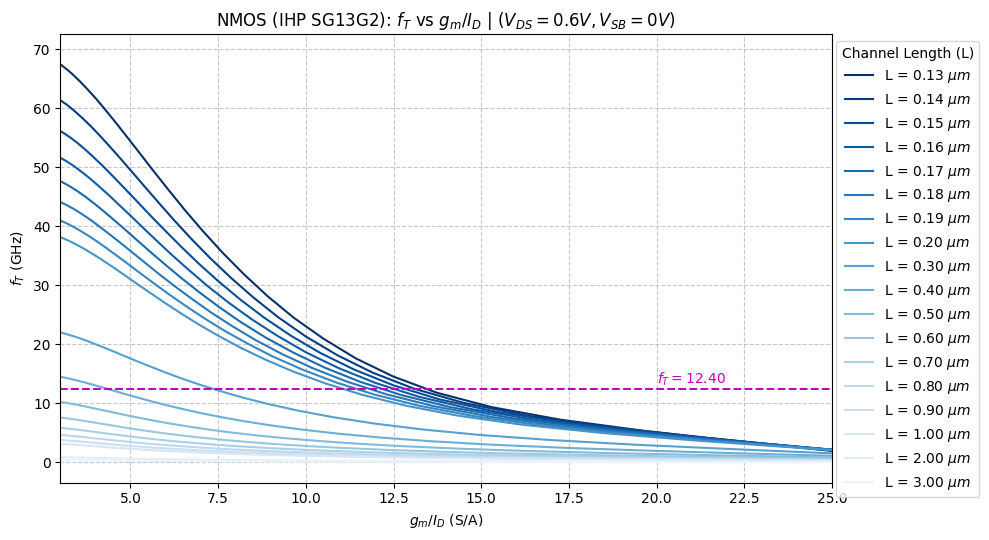

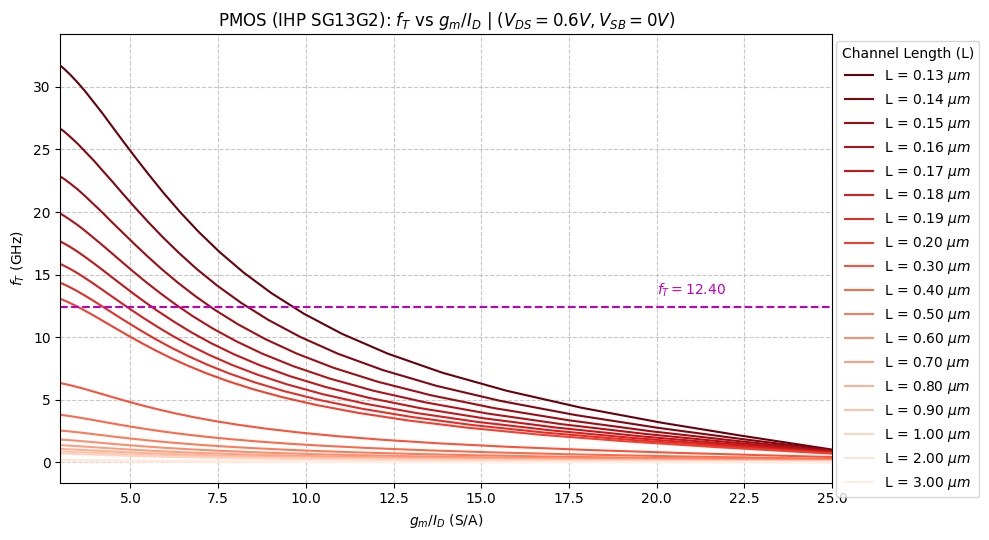

In [7]:
# =============================
# NMOS & PMOS fT VS gm/ID PLOTS
# =============================
# Plotting Function
def plot_ft_vs_gmid(device_data, device_name, color_map):
    fig = plt.figure(figsize=(10, 5.5))
    
    # Extract all available Lengths from the LUT
    L_values = np.unique(device_data['L'])

    # Loop through each 'L' and plot
    for i, L_val in enumerate(L_values):
        # Look up 'GM_ID' while sweeping VGS, holding L, VDS, and VSB constant
        gm_ID = device_data.lookup('GM_ID', VDS=VDD/2, VSB=0, L=L_val)
        fT = device_data.lookup('GM_CGG', VDS=VDD/2, VSB=0, L=L_val)/2/np.pi
        
        # Plotting
        plt.plot(gm_ID, fT*1e-9, label=rf'L = {L_val:.2f} $\mu m$', color=color_map(i / len(L_values)))

    # Formatting the Plot
    plt.title(fr'{device_name}: $f_T$ vs $g_m/I_D$ | ($V_{{DS}}={VDD/2}V, V_{{SB}}={0}V$)')
    plt.xlabel(r'$g_m/I_D$ (S/A)')
    plt.ylabel(r'$f_T$ (GHz)')
    plt.xlim(3, 25)

    # Horizontal fT requirement line (fT >= 5 * 2.48GHz)
    plt.axhline(y=5*f_max*1e-9, color='m', linestyle='--')
    plt.text(20, (5*f_max*1e-9)+1, f'$f_T = {5*f_max*1e-9:.2f}$', color='m')

    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.2, 1), loc='upper right', title="Channel Length (L)")
    plt.tight_layout()
    plt.show()

# Generate Plots
plot_ft_vs_gmid(NCH, "NMOS (IHP SG13G2)", plt.cm.Blues_r)
plot_ft_vs_gmid(PCH, "PMOS (IHP SG13G2)", plt.cm.Reds_r)

In [8]:
# ============================
# Transistor Sizing Parameters
# ============================
L_cc = 0.13     # Chosen channel length (μm) of cross-coupled pairs
L_tl = 0.5      # Chosen channel length (μm) of tail current source
V_X = 0.2       # VDS for tail current source device
I_bias = 80e-6  # Desired bias current for the VCO

V_DC = (VDD + V_X) / 2  # Midpoint voltage for lookup
print(f"Output Common-Mode Voltage (V_DC): {V_DC:.2f} V")

Output Common-Mode Voltage (V_DC): 0.70 V


In [9]:
# =============================
# M3 & M4 Sizing via gm/Id LUTs
# =============================
VGS_34 = VDD - V_DC; VDS_34 = VDD - V_DC; VSB_34 = 0
print(f"M3/M4 Sizing at VGS={VGS_34:.2f}V, VDS={VDS_34:.2f}V, VSB={VSB_34:.2f}V, L={L_cc:.2f}μm:")

gm_ID_34 = PCH.lookup('GM_ID', VGS=VGS_34, VDS=VDS_34, VSB=VSB_34, L=L_cc)
print(f"  gm/ID: {gm_ID_34:.2f} S/A")
fT_34 = PCH.lookup('GM_CGG', VGS=VGS_34, VDS=VDS_34, VSB=VSB_34, L=L_cc)/2/np.pi
print(f"  fT: {fT_34*1e-9:.2f} GHz")
vth_34 = PCH.lookup('VT', VGS=VGS_34, VDS=VDS_34, VSB=VSB_34, L=L_cc)
print(f"  Vth: {vth_34:.2f} V | Vov: {VGS_34 - vth_34:.2f} V")

ID_branch = gm_min / gm_ID_34
print(f"  ID: {ID_branch*1e6:.2f} μA | gm: {gm_ID_34*ID_branch*1e3:.2f} mS")
W_34 = ID_branch / PCH.lookup('ID_W', VGS=VGS_34, VDS=VDS_34, VSB=VSB_34, L=L_cc)
print(f"  W: {W_34:.2f} μm")

M3/M4 Sizing at VGS=0.50V, VDS=0.50V, VSB=0.00V, L=0.13μm:
  gm/ID: 14.12 S/A
  fT: 6.71 GHz
  Vth: 0.42 V | Vov: 0.08 V
  ID: 137.52 μA | gm: 1.94 mS
  W: 34.52 μm


In [10]:
# =============================
# M1 & M2 Sizing via gm/Id LUTs
# =============================
VGS_12 = V_DC - V_X; VDS_12 = V_DC - V_X; VSB_12 = V_X
print(f"M1/M2 Sizing at VGS={VGS_12:.2f}V, VDS={VDS_12:.2f}V, VSB={VSB_12:.2f}V, L={L_cc:.2f}μm:")

gm_ID_12 = NCH.lookup('GM_ID', VGS=VGS_12, VDS=VDS_12, VSB=VSB_12, L=L_cc)
print(f"  gm/ID: {gm_ID_12:.2f} S/A")
fT_12 = NCH.lookup('GM_CGG', VGS=VGS_12, VDS=VDS_12, VSB=VSB_12, L=L_cc)/2/np.pi
print(f"  fT: {fT_12*1e-9:.2f} GHz")
vth_12 = NCH.lookup('VT', VGS=VGS_12, VDS=VDS_12, VSB=VSB_12, L=L_cc)
print(f"  Vth: {vth_12:.2f} V | Vov: {VGS_12 - vth_12:.2f} V")

print(f"  ID: {ID_branch*1e6:.2f} μA | gm: {gm_ID_12*ID_branch*1e3:.2f} mS")
W_12 = ID_branch / NCH.lookup('ID_W', VGS=VGS_12, VDS=VDS_12, VSB=VSB_12, L=L_cc)
print(f"  W: {W_12:.2f} μm")

M1/M2 Sizing at VGS=0.50V, VDS=0.50V, VSB=0.20V, L=0.13μm:
  gm/ID: 15.33 S/A
  fT: 9.01 GHz
  Vth: 0.45 V | Vov: 0.05 V
  ID: 137.52 μA | gm: 2.11 mS
  W: 25.11 μm


In [11]:
# ========================
# M5 Sizing via gm/Id LUTs
# ========================
gm_ID_5 = 14  # Chosen gm/ID target for tail current source based on plots and design trade-offs
VDS_5 = V_X; VSB_5 = 0
print(f"M5 Sizing at gm/ID={gm_ID_5:.2f} S/A, VDS={VDS_5:.2f}V, VSB={VSB_5:.2f}V, L={L_tl:.2f}μm:")

I_tail = 2 * ID_branch  # Tail current is twice the branch current to ensure proper biasing of the cross-coupled pair
print(f"  ID: {I_tail*1e5:.2f} μA")
gds_5 = (gm_ID_5 * I_tail) / NCH.lookup('GM_GDS', GM_ID=gm_ID_5, VDS=VDS_5, VSB=VSB_5, L=L_tl)
print(f"  ro: {(1/gds_5)*1e-3:.2f} kΩ")
Vgs_5 = NCH.lookupVGS(GM_ID=gm_ID_5, VDS=VDS_5, VSB=VSB_5, L=L_tl)
vth_5 = NCH.lookup('VT', VGS=Vgs_5, VDS=VDS_5, VSB=VSB_5, L=L_tl)
print(f"  Vgs: {Vgs_5:.2f} V | Vth: {vth_5:.2f} V | Vov: {Vgs_5 - vth_5:.2f} V")

print(f"  ID: {I_tail*1e5:.2f} μA")
W_5 = I_tail / NCH.lookup('ID_W', GM_ID=gm_ID_5, VDS=VDS_5, VSB=VSB_5, L=L_tl)
print(f"  W: {W_5:.2f} μm")

M5 Sizing at gm/ID=14.00 S/A, VDS=0.20V, VSB=0.00V, L=0.50μm:
  ID: 27.50 μA
  ro: 4.10 kΩ
  Vgs: 0.37 V | Vth: 0.27 V | Vov: 0.10 V
  ID: 27.50 μA
  W: 70.29 μm


In [12]:
# ========================
# M6 Sizing via gm/Id LUTs
# ========================
VGS_6 = Vgs_5; VDS_6 = Vgs_5; VSB_6 = 0
print(f"M6 Sizing at VGS={VGS_6:.2f}V, VDS={VDS_6:.2f}V, VSB={VSB_6:.2f}V, L={L_tl:.2f}μm:")

gm_ID_6 = NCH.lookup('GM_ID', VGS=VGS_6, VDS=VDS_6, VSB=VSB_6, L=L_tl)
print(f"  gm/ID: {gm_ID_6:.2f} S/A")
print(f"  ID: {I_bias*1e6:.2f} μA")
gds_6 = (gm_ID_6 * I_bias) / NCH.lookup('GM_GDS', VGS=VGS_6, VDS=VDS_6, VSB=VSB_6, L=L_tl)
print(f"  ro: {(1/gds_6)*1e-3:.2f} kΩ")
vth_6 = NCH.lookup('VT', VGS=VGS_6, VDS=VDS_6, VSB=VSB_6, L=L_tl)
print(f"  Vth: {vth_6:.2f} V | Vov: {VGS_6 - vth_6:.2f} V")

W_6 = I_bias / NCH.lookup('ID_W', VGS=VGS_6, VDS=VDS_6, VSB=VSB_6, L=L_tl)
print(f"  W: {W_6:.2f} μm")

M6 Sizing at VGS=0.37V, VDS=0.37V, VSB=0.00V, L=0.50μm:
  gm/ID: 13.48 S/A
  ID: 80.00 μA
  ro: 19.37 kΩ
  Vth: 0.27 V | Vov: 0.10 V
  W: 17.95 μm


In [13]:
# ========================
# M7 Sizing via gm/Id LUTs
# ========================
VGS_7 = VDD/2; VDS_7 = VDD - VGS_6; VSB_7 = 0
print(f"M7 Sizing at VGS={VGS_7:.2f}V, VDS={VDS_7:.2f}V, VSB={VSB_7:.2f}V, L={L_tl:.2f}μm:")

gm_ID_7 = PCH.lookup('GM_ID', VGS=VGS_7, VDS=VDS_7, VSB=VSB_7, L=L_tl)
print(f"  gm/ID: {gm_ID_7:.2f} S/A")
print(f"  ID: {I_bias*1e6:.2f} μA")
gds_7 = (gm_ID_7 * I_bias) / PCH.lookup('GM_GDS', VGS=VGS_7, VDS=VDS_7, VSB=VSB_7, L=L_tl)
print(f"  ro: {(1/gds_7)*1e-3:.2f} kΩ")
vth_7 = PCH.lookup('VT', VGS=VGS_7, VDS=VDS_7, VSB=VSB_7, L=L_tl)
print(f"  Vth: {vth_7:.2f} V | Vov: {VGS_7 - vth_7:.2f} V")

W_7 = I_bias / PCH.lookup('ID_W', VGS=VGS_7, VDS=VDS_7, VSB=VSB_7, L=L_tl)
print(f"  W: {W_7:.2f} μm")

M7 Sizing at VGS=0.60V, VDS=0.83V, VSB=0.00V, L=0.50μm:
  gm/ID: 7.71 S/A
  ID: 80.00 μA
  ro: 161.19 kΩ
  Vth: 0.36 V | Vov: 0.24 V
  W: 16.72 μm


In [14]:
# ========================================================
# M8/M10 and M9/M11 Sizing via gm/Id LUTs (Output Buffers)
# ========================================================
thresh = 0.7
L_BF = 0.13  # Channel length for output buffer devices
I_buf = 100e-6  # Desired bias current for output buffer devices

VGS_8_10 = VDD - thresh; VDS_8_10 = VDD - thresh; VSB_8_10 = 0  # PMOS

gm_ID_8_10 = PCH.lookup('GM_ID', VGS=VGS_8_10, VDS=VDS_8_10, VSB=VSB_8_10, L=L_BF)
print(f"  gm/ID: {gm_ID_8_10:.2f} S/A")
print(f"  ID: {I_buf*1e6:.2f} μA")
fT_8_10 = PCH.lookup('GM_CGG', VGS=VGS_8_10, VDS=VDS_8_10, VSB=VSB_8_10, L=L_BF)/2/np.pi
Cgg_8_10 = PCH.lookup('CGG', VGS=VGS_8_10, VDS=VDS_8_10, VSB=VSB_8_10, L=L_BF)
print(f"  fT: {fT_8_10*1e-9:.2f} GHz | Cgg: {Cgg_8_10*1e15:.2f} fF")
vth_8_10 = PCH.lookup('VT', VGS=VGS_8_10, VDS=VDS_8_10, VSB=VSB_8_10, L=L_BF)
print(f"  Vth: {vth_8_10:.2f} V | Vov: {VGS_8_10 - vth_8_10:.2f} V")

W_8_10 = I_buf / PCH.lookup('ID_W', VGS=VGS_8_10, VDS=VDS_8_10, VSB=VSB_8_10, L=L_BF)
print(f"  W: {W_8_10:.2f} μm\n")

VGS_9_11 = thresh; VDS_9_11 = thresh; VSB_9_11 = 0  # NMOS

gm_ID_9_11 = NCH.lookup('GM_ID', VGS=VGS_9_11, VDS=VDS_9_11, VSB=VSB_9_11, L=L_BF)
print(f"  gm/ID: {gm_ID_9_11:.2f} S/A")
print(f"  ID: {I_buf*1e6:.2f} μA")
fT_9_11 = NCH.lookup('GM_CGG', VGS=VGS_9_11, VDS=VDS_9_11, VSB=VSB_9_11, L=L_BF)/2/np.pi
Cgg_9_11 = NCH.lookup('CGG', VGS=VGS_9_11, VDS=VDS_9_11, VSB=VSB_9_11, L=L_BF)
print(f"  fT: {fT_9_11*1e-9:.2f} GHz | Cgg: {Cgg_9_11*1e15:.2f} fF")
vth_9_11 = NCH.lookup('VT', VGS=VGS_9_11, VDS=VDS_9_11, VSB=VSB_9_11, L=L_BF)
print(f"  Vth: {vth_9_11:.2f} V | Vov: {VGS_9_11 - vth_9_11:.2f} V")

W_9_11 = I_buf / NCH.lookup('ID_W', VGS=VGS_9_11, VDS=VDS_9_11, VSB=VSB_9_11, L=L_BF)
print(f"  W: {W_9_11:.2f} μm\n")

  gm/ID: 14.12 S/A
  ID: 100.00 μA
  fT: 6.71 GHz | Cgg: 6.67 fF
  Vth: 0.42 V | Vov: 0.08 V
  W: 25.10 μm

  gm/ID: 6.97 S/A
  ID: 100.00 μA
  fT: 40.41 GHz | Cgg: 8.37 fF
  Vth: 0.43 V | Vov: 0.27 V
  W: 1.64 μm



In [15]:
# ====================================================
# Parasitic Capacitance Extraction & Domain Conversion
# ====================================================
CGS_34 = W_34 * PCH.lookup('CGS_W', VGS=VGS_34, VDS=VDS_34, VSB=0, L=L_cc)
CGD_34 = W_34 * PCH.lookup('CGD_W', VGS=VGS_34, VDS=VDS_34, VSB=0, L=L_cc)
CGS_12 = W_12 * NCH.lookup('CGS_W', VGS=VGS_12, VDS=VDS_12, VSB=V_X, L=L_cc)
CGD_12 = W_12 * NCH.lookup('CGD_W', VGS=VGS_12, VDS=VDS_12, VSB=V_X, L=L_cc)
CGG_8_10 = Cgg_8_10
CGG_9_11 = Cgg_9_11

# Total parasitic capacitance from OUTp node to AC Ground
# Considering Miller effect on CGD
C_tx_se = CGS_34 + CGS_12 + (4 * CGD_34) + (4 * CGD_12) + CGG_8_10 + CGG_9_11
print(f"Total Effective Single-Ended Capacitance (Parasitic) at VCO Node: {C_tx_se*1e15:.4f} fF")

# Convert Single-Ended capacitance to Equivalent Differential Capacitance
C_tx_diff = C_tx_se / 2
print(f"Equivalent Differential Capacitance (Parasitic) at VCO Node: {C_tx_diff*1e15:.4f} fF")

Total Effective Single-Ended Capacitance (Parasitic) at VCO Node: 189.7103 fF
Equivalent Differential Capacitance (Parasitic) at VCO Node: 94.8552 fF


In [16]:
# ==============================================
# Tuning & Varactor Budget (Differential Domain)
# ==============================================
# Remaining DIFFERENTIAL capacitance budget for varactor + fixed MIM cap
C_budget_diff = C_tot_diff - C_tx_diff - C_ind_par_diff
print(f"Total Differential Capacitance Budget for Varactor + MIM: {C_budget_diff*1e15:.4f} fF")

# Required delta C for tuning range (Differential)
w_min = 2 * np.pi * f_min
w_max = 2 * np.pi * f_max
C_max_diff = 1.0 / ((w_min**2) * L_diff)
C_min_diff = 1.0 / ((w_max**2) * L_diff)

Delta_C_diff = C_max_diff - C_min_diff
print(f"Required Differential Capacitance Tuning Range (Delta C): {Delta_C_diff*1e15:.4f} fF")

Total Differential Capacitance Budget for Varactor + MIM: 898.6324 fF
Required Differential Capacitance Tuning Range (Delta C): 69.7853 fF
